### Exploratory Data Analysis in Python

In [77]:
# 1. Importing the required libraries for EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline     
sns.set(color_codes=True)

In [78]:
## 2. Loading and Inspecting the Data

# %%
# Load the dataset
df = pd.read_csv("data.csv")

# Display the shape of the data
df.shape

(11914, 16)

In [79]:
# Display the top 5 rows of the data
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [80]:
# Display the bottom 5 rows of the data
df.tail()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


In [81]:
# Check data types of each column
df.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

### 3. Data Cleaning

In [82]:
# Drop irrelevant columns
df = df.drop(['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)
df.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [83]:
# Rename columns for better readability
df = df.rename(columns={
    "Engine HP": "HP", 
    "Engine Cylinders": "Cylinders", 
    "Transmission Type": "Transmission", 
    "Driven_Wheels": "Drive Mode",
    "highway MPG": "MPG-H", 
    "city mpg": "MPG-C", 
    "MSRP": "Price"
})
df.head()

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [84]:
# Checking for duplicates
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows: ", duplicate_rows_df.shape)

Number of duplicate rows:  (989, 10)


In [85]:
# Drop duplicates if any
df = df.drop_duplicates()
df.shape

(10925, 10)

In [86]:
# Checking for missing values
df.isnull().sum()

# %%
# Drop rows with missing values
df = df.dropna()
df.shape

(10827, 10)

### 4. Descriptive Statistics (Univariate Analysis)

In [87]:
# Descriptive statistics for numerical columns
df.describe()

,Year,HP,Cylinders,MPG-H,MPG-C,Price
count,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,1.082700e+04
mean,2010.896370,254.553062,5.691604,26.308119,19.327607,4.249325e+04
std,7.029534,109.841537,1.768551,7.504652,6.643567,6.229451e+04
min,1990.000000,55.000000,0.000000,12.000000,7.000000,2.000000e+03
25%,2007.000000,173.000000,4.000000,22.000000,16.000000,2.197250e+04
50%,2015.000000,240.000000,6.000000,25.000000,18.000000,3.084500e+04
75%,2016.000000,303.000000,6.000000,30.000000,22.000000,4.330000e+04
max,2017.000000,1001.000000,16.000000,354.000000,137.000000,2.065902e+06


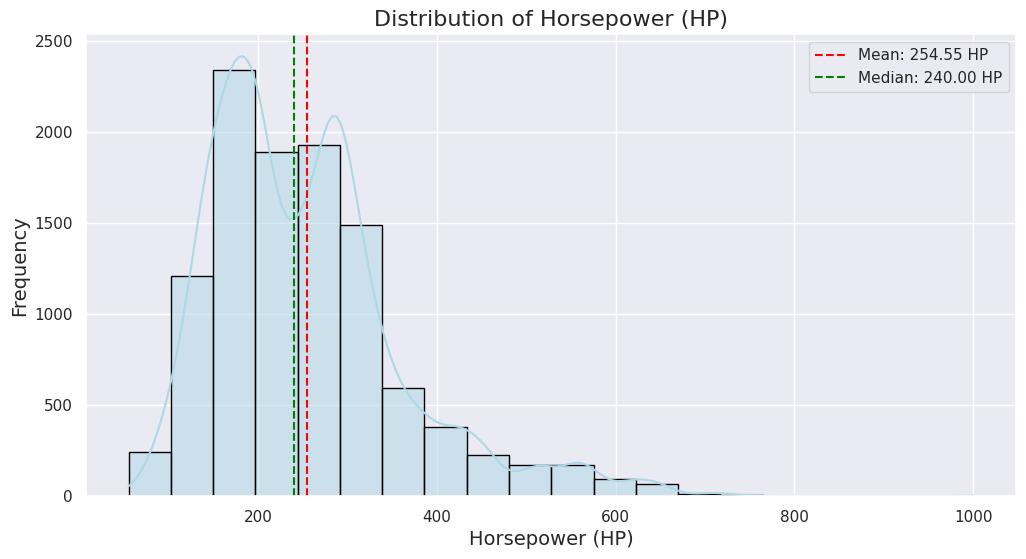

In [88]:
# Plot distribution of Horsepower (HP)
plt.figure(figsize=(12, 6))
sns.histplot(df['HP'], bins=20, kde=True, color='lightblue', edgecolor='black')
plt.axvline(df['HP'].mean(), color='red', linestyle='--', label=f'Mean: {df["HP"].mean():.2f} HP')
plt.axvline(df['HP'].median(), color='green', linestyle='--', label=f'Median: {df["HP"].median():.2f} HP')
plt.title('Distribution of Horsepower (HP)', fontsize=16)
plt.xlabel('Horsepower (HP)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.show()

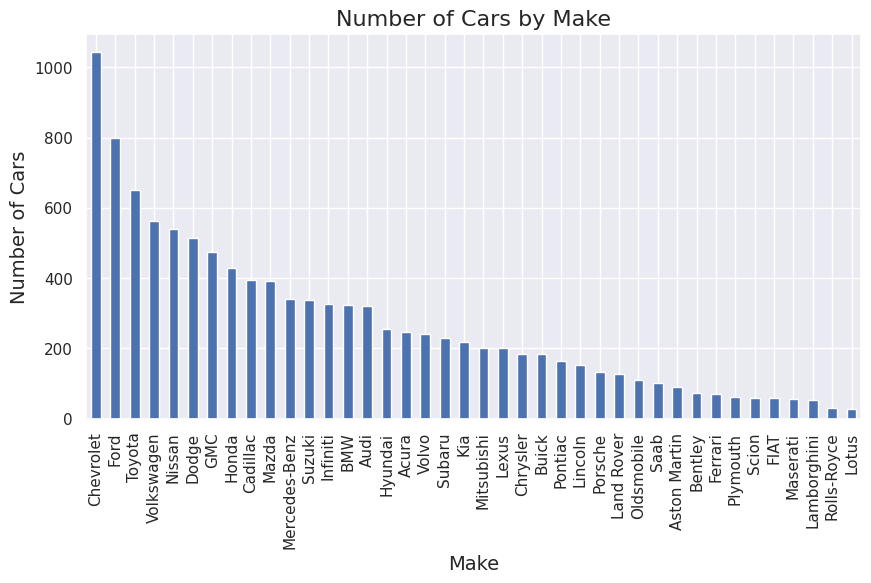

In [89]:
# Bar plot for the number of cars by Make
plt.figure(figsize=(10, 5))
df.Make.value_counts().nlargest(40).plot(kind='bar')
plt.title("Number of Cars by Make", fontsize=16)
plt.ylabel('Number of Cars', fontsize=14)
plt.xlabel('Make', fontsize=14)
plt.show()

### 5. Bivariate Analysis

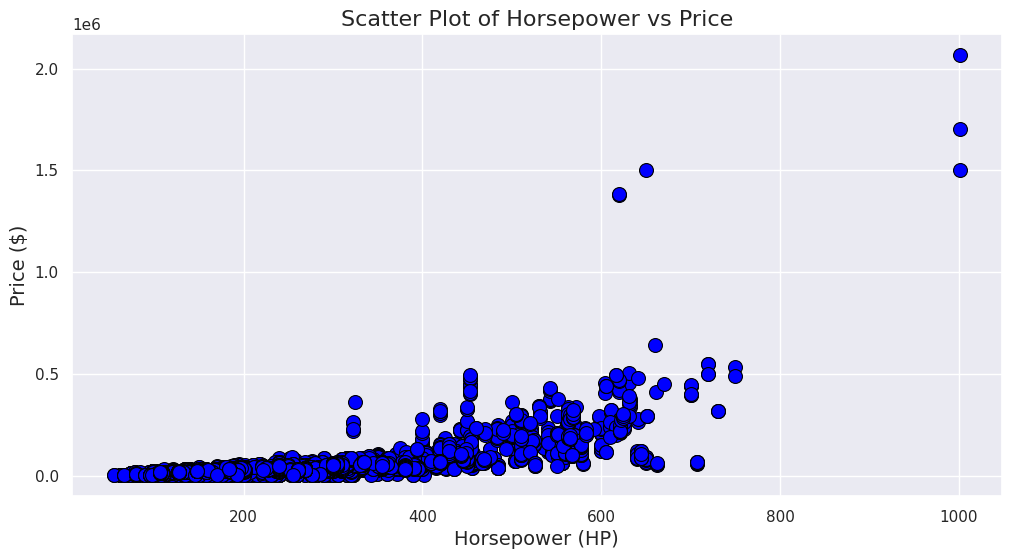

In [90]:
# Scatter plot of Horsepower vs Price
plt.figure(figsize=(12, 6))
sns.scatterplot(x='HP', y='Price', data=df, color='blue', s=100, edgecolor='black')
plt.title('Scatter Plot of Horsepower vs Price', fontsize=16)
plt.xlabel('Horsepower (HP)', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.grid(True)
plt.show()

/tmp/ipykernel_113220/4024149271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HP', y='Price', data=df, palette='Set2')


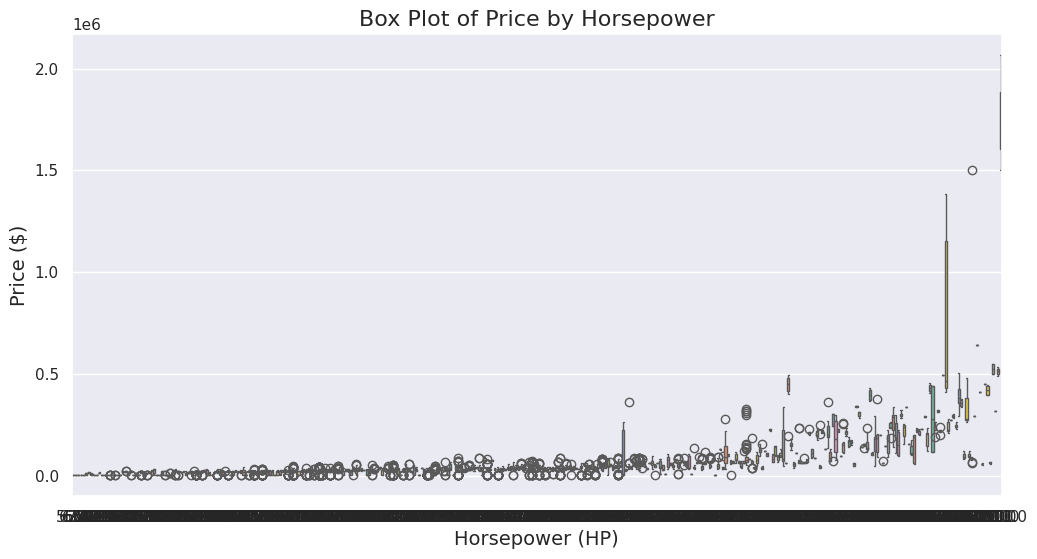

In [91]:
# Box plot of Price by Horsepower
plt.figure(figsize=(12, 6))
sns.boxplot(x='HP', y='Price', data=df, palette='Set2')
plt.title('Box Plot of Price by Horsepower', fontsize=16)
plt.xlabel('Horsepower (HP)', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.show()

/tmp/ipykernel_113220/486083810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cylinders', y='Price', data=df, palette='Set2')


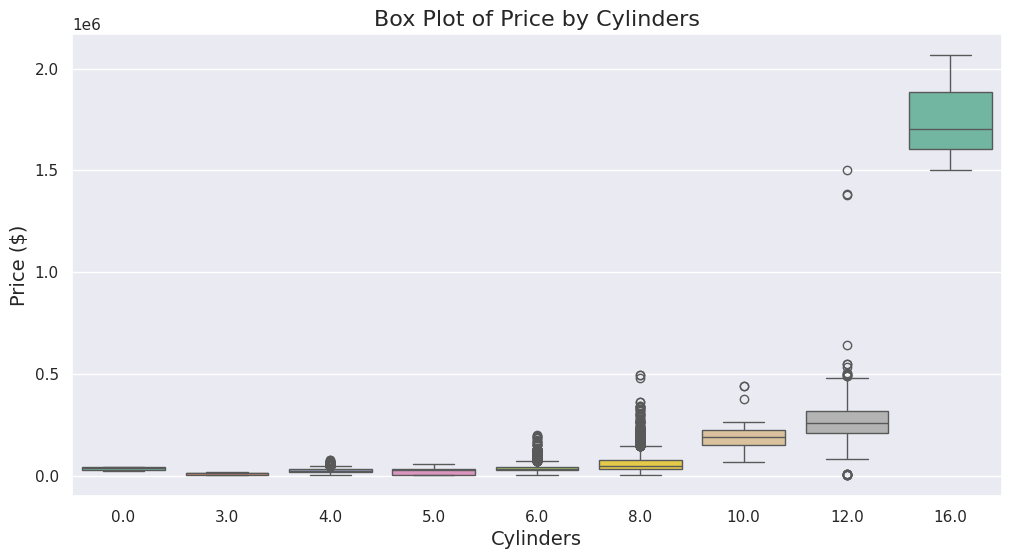

In [92]:
# Box plot of Price by Cylinders
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cylinders', y='Price', data=df, palette='Set2')
plt.title('Box Plot of Price by Cylinders', fontsize=16)
plt.xlabel('Cylinders', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.show()

### 6. Correlation Analysis (Multivariate Analysis)

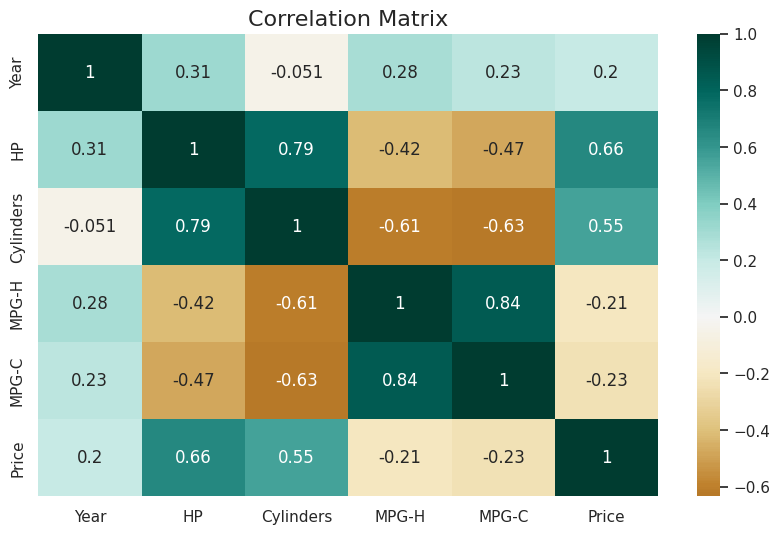

In [93]:
# Correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='BrBG', center=0)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

### 7. Advanced Binning and Grouping

/tmp/ipykernel_113220/3361109336.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HP_Category', y='Price', data=df, palette='viridis')


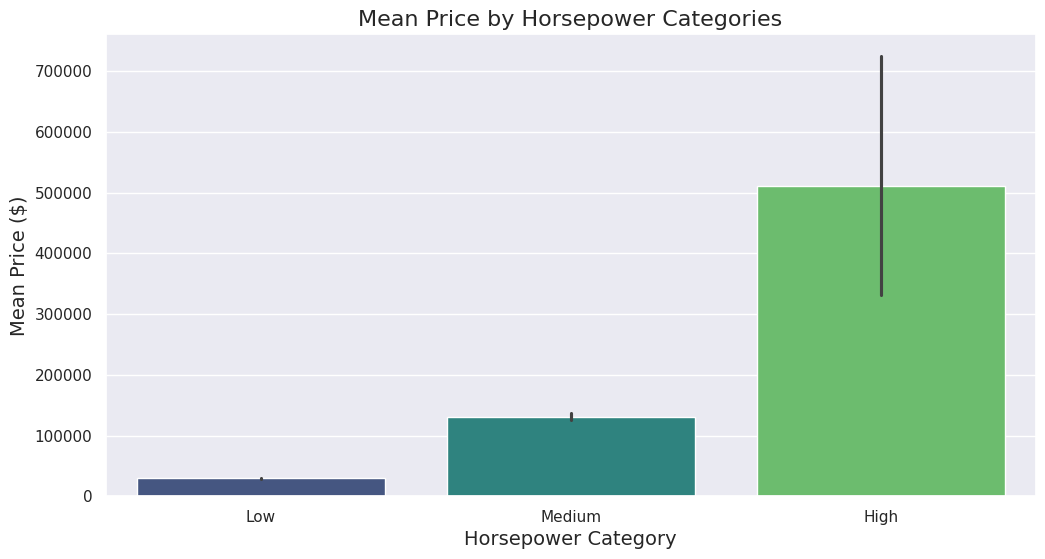

In [94]:
# Categorize Horsepower (HP) into bins
df['HP_Category'] = pd.cut(df['HP'], bins=3, labels=['Low', 'Medium', 'High'])

# Bar plot of Mean Price by HP Categories
plt.figure(figsize=(12, 6))
sns.barplot(x='HP_Category', y='Price', data=df, palette='viridis')
plt.title('Mean Price by Horsepower Categories', fontsize=16)
plt.xlabel('Horsepower Category', fontsize=14)
plt.ylabel('Mean Price ($)', fontsize=14)
plt.show()

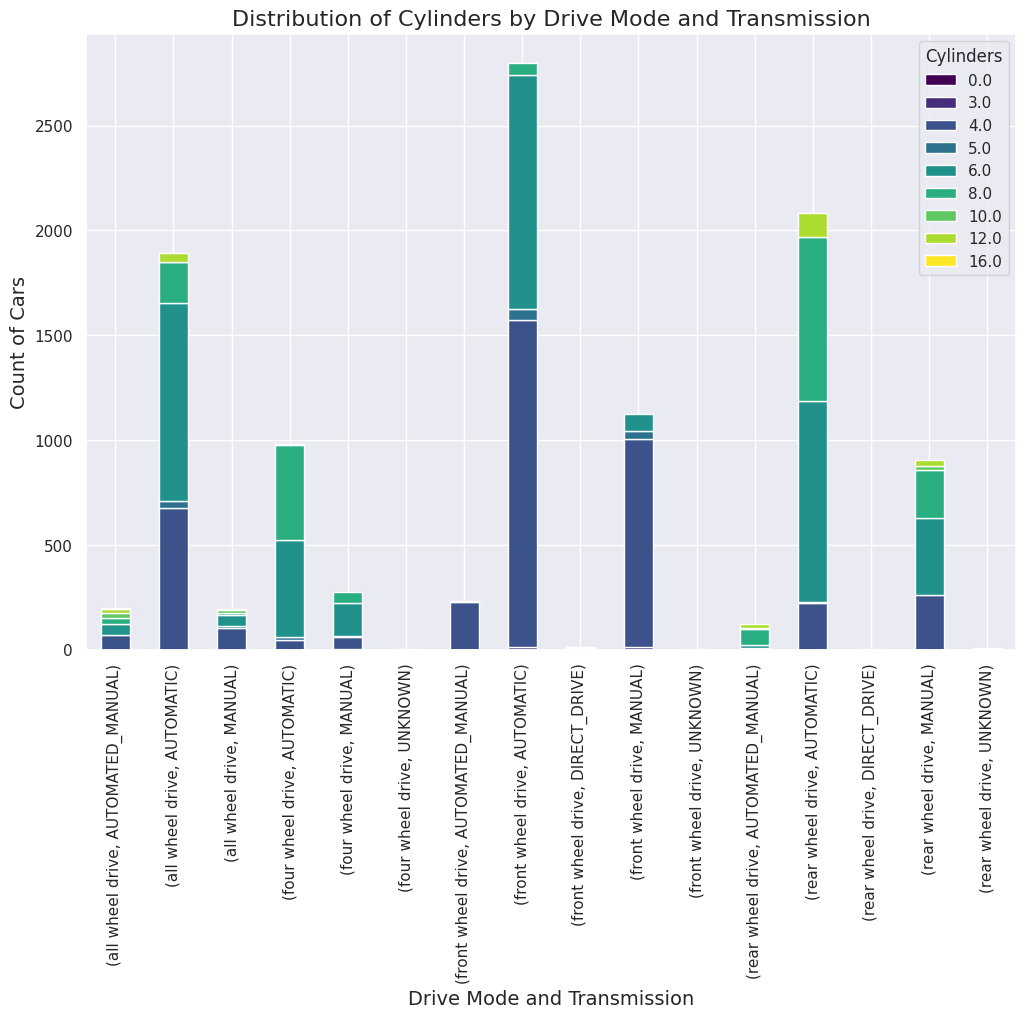

In [95]:
# Stacked bar plot: Distribution of Cylinders by Drive Mode and Transmission
data = df.groupby(['Drive Mode', 'Transmission', 'Cylinders']).size().unstack()
data.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title('Distribution of Cylinders by Drive Mode and Transmission', fontsize=16)
plt.xlabel('Drive Mode and Transmission', fontsize=14)
plt.ylabel('Count of Cars', fontsize=14)
plt.xticks(rotation=90)
plt.legend(title='Cylinders')
plt.show()

### 8. Outlier Detection and Handling

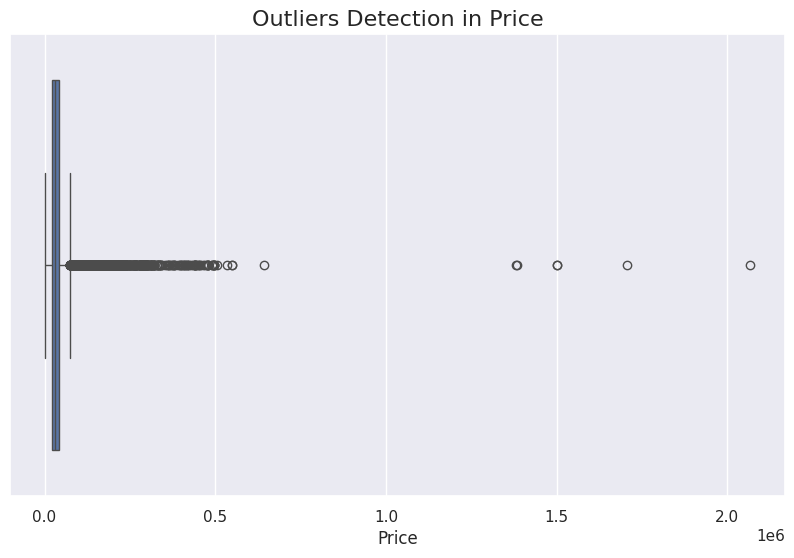

In [96]:
# Detect outliers in Price using Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Price'])
plt.title('Outliers Detection in Price', fontsize=16)
plt.show()


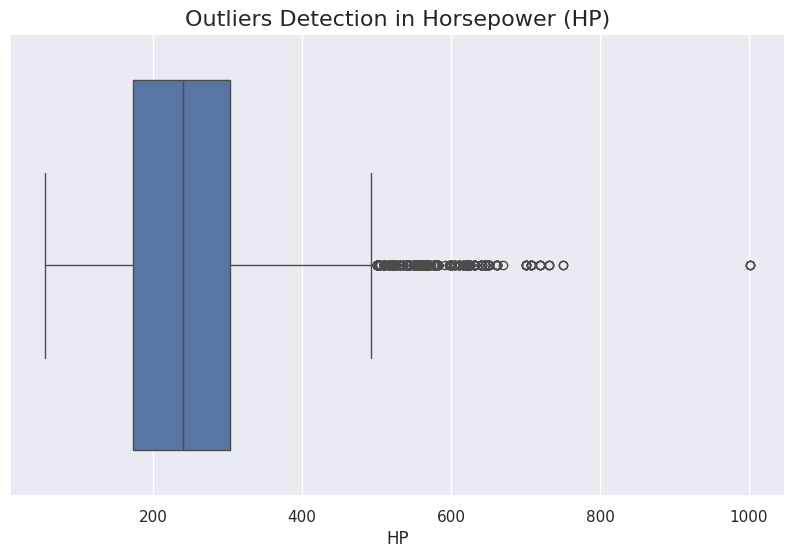

In [97]:
# Detect outliers in Horsepower (HP)
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['HP'])
plt.title('Outliers Detection in Horsepower (HP)', fontsize=16)
plt.show()

In [98]:
# Outlier removal using IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

In [99]:
df_clean = df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]
df_clean.shape

(9191, 11)